In [1]:
import torch, torchvision
print(torch.__version__, torchvision.__version__)
print("CUDA:", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))   # expect "Tesla T4"

2.11.0+cu130 0.26.0+cu130
CUDA: True
Tesla T4


In [3]:
from google.colab import drive
from pathlib import Path
import shutil

drive.mount('/content/drive')

DRIVE_CACHE = Path('/content/drive/MyDrive/datasets/oxford-iiit-pet')
LOCAL_ROOT  = Path('/content/data')
LOCAL_DS    = LOCAL_ROOT / 'oxford-iiit-pet'   # the subfolder torchvision uses
ARCHIVES    = ['images.tar.gz', 'annotations.tar.gz']

LOCAL_DS.mkdir(parents=True, exist_ok=True)
for f in ARCHIVES:
    if (DRIVE_CACHE / f).exists() and not (LOCAL_DS / f).exists():
        print(f"Restoring {f} from Drive...")
        shutil.copy(DRIVE_CACHE / f, LOCAL_DS / f)

Mounted at /content/drive


In [4]:
from torchvision.datasets import OxfordIIITPet

trainval_ds = OxfordIIITPet(LOCAL_ROOT, split='trainval',
                            target_types='segmentation', download=True)
test_ds     = OxfordIIITPet(LOCAL_ROOT, split='test',
                            target_types='segmentation', download=True)
print(len(trainval_ds), len(test_ds))   # expect 3680 3669

DRIVE_CACHE.mkdir(parents=True, exist_ok=True)
for f in ARCHIVES:
    if not (DRIVE_CACHE / f).exists():
        print(f"Backing up {f} to Drive...")
        shutil.copy(LOCAL_DS / f, DRIVE_CACHE / f)

100%|██████████| 792M/792M [00:31<00:00, 25.2MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.32MB/s]


3680 3669
Backing up images.tar.gz to Drive...
Backing up annotations.tar.gz to Drive...


<class 'PIL.Image.Image'> (394, 500) RGB
<class 'PIL.PngImagePlugin.PngImageFile'> (394, 500) L
mask values: [1 2 3]
[(394, 500), (450, 313), (500, 465), (500, 351), (600, 363)]
pixel share fg/bg/boundary: [0.26  0.617 0.122]


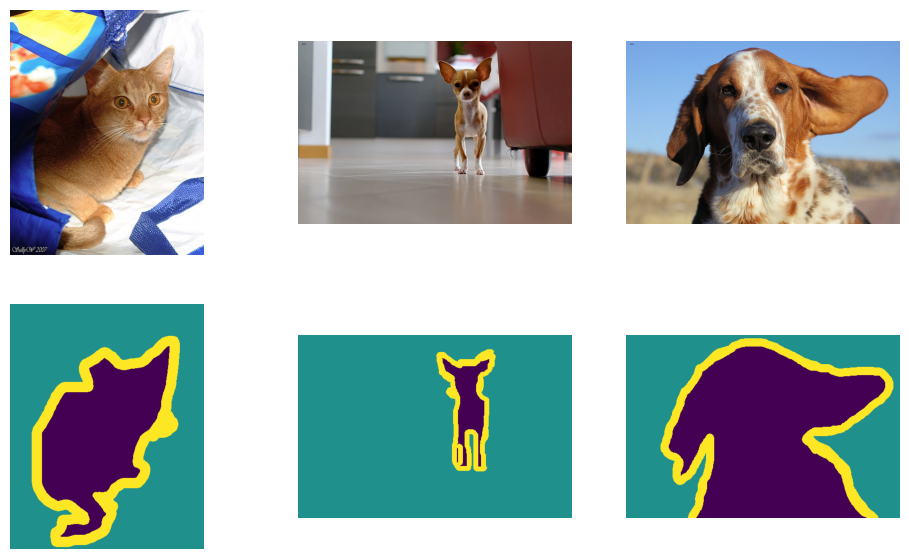

In [5]:
import numpy as np
import matplotlib.pyplot as plt

img, mask = trainval_ds[0]
print(type(img), img.size, img.mode)
print(type(mask), mask.size, mask.mode)
print("mask values:", np.unique(np.array(mask)))

# A few image sizes -- are they uniform?
print([trainval_ds[i][0].size for i in range(5)])

# Class balance over 200 samples
counts = np.zeros(4)
for i in range(200):
    counts += np.bincount(np.array(trainval_ds[i][1]).ravel(), minlength=4)
print("pixel share fg/bg/boundary:", (counts[1:] / counts.sum()).round(3))

# Look at three pairs
fig, ax = plt.subplots(2, 3, figsize=(12, 7))
for k, i in enumerate([0, 500, 2000]):
    im, m = trainval_ds[i]
    ax[0, k].imshow(im); ax[0, k].axis('off')
    ax[1, k].imshow(np.array(m)); ax[1, k].axis('off')
plt.show()

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import tv_tensors
from torchvision.transforms import v2

IMG_SIZE = 256
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]   # ImageNet stats

to_dtype = v2.ToDtype({tv_tensors.Image: torch.float32,
                       tv_tensors.Mask: torch.int64,
                       "others": None}, scale=True)   # scales image to [0,1], not the mask

train_tf = v2.Compose([
    v2.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0), antialias=True),
    v2.RandomHorizontalFlip(),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    to_dtype,
    v2.Normalize(MEAN, STD),
])

eval_tf = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
    to_dtype,
    v2.Normalize(MEAN, STD),
])

In [19]:
class PetSeg(Dataset):
    def __init__(self, base, transform):
        self.base, self.transform = base, transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        img, mask = self.base[i]                     # two PIL images
        img  = tv_tensors.Image(img)                 # 3 x H x W, uint8
        mask = tv_tensors.Mask(mask)                 # 1 x H x W, uint8
        img, mask = self.transform(img, mask)        # same geometry for both
        return img, mask.squeeze(0) - 1              # H x W, values 0/1/2

g = torch.Generator().manual_seed(42)
train_sub, val_sub = random_split(trainval_ds, [3312, 368], generator=g)

train_set = PetSeg(train_sub, train_tf)
val_set   = PetSeg(val_sub,   eval_tf)
test_set  = PetSeg(test_ds,   eval_tf)

BATCH = 32
train_loader = DataLoader(train_set, BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  BATCH, shuffle=False, num_workers=2, pin_memory=True)

Note: the output of this cell, and of the model check further down, was produced at IMG_SIZE = 128, before the switch to 256 for run 2.

torch.Size([32, 3, 128, 128]) torch.float32
torch.Size([32, 128, 128]) torch.int64
tensor([0, 1, 2])


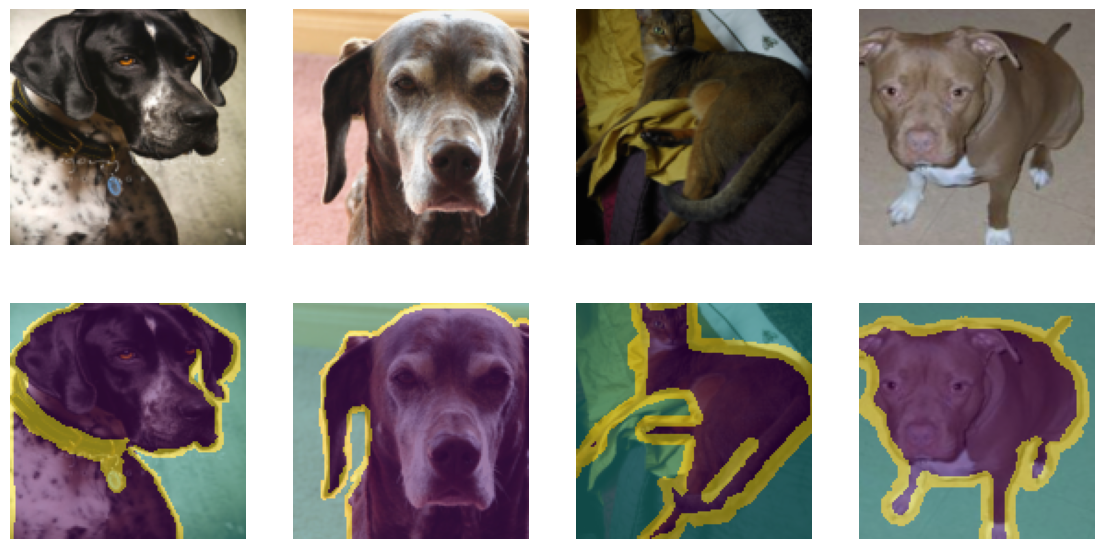

In [8]:
x, y = next(iter(train_loader))
print(x.shape, x.dtype)        # expect [32, 3, 128, 128] float32
print(y.shape, y.dtype)        # expect [32, 128, 128] int64
print(y.unique())              # expect tensor([0, 1, 2])

mean = torch.tensor(MEAN).view(3, 1, 1)
std  = torch.tensor(STD).view(3, 1, 1)

fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for k in range(4):
    im = (x[k] * std + mean).clamp(0, 1).permute(1, 2, 0)   # undo normalisation
    ax[0, k].imshow(im);                              ax[0, k].axis('off')
    ax[1, k].imshow(im); ax[1, k].imshow(y[k], alpha=0.5); ax[1, k].axis('off')
plt.show()

In [9]:
import torch.nn as nn

class DoubleConv(nn.Module):
    """(conv 3x3 -> BatchNorm -> ReLU) twice. Keeps H and W unchanged."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, n_classes=3, base=32):
        super().__init__()
        c = [base, base * 2, base * 4, base * 8, base * 16]   # 32, 64, 128, 256, 512

        # Encoder: four DoubleConv blocks, each followed by a pool
        self.downs = nn.ModuleList([
            DoubleConv(in_ch, c[0]),
            DoubleConv(c[0], c[1]),
            DoubleConv(c[1], c[2]),
            DoubleConv(c[2], c[3]),
        ])
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(c[3], c[4])

        # Decoder: upsample (halves channels), then DoubleConv on the concatenation
        self.ups = nn.ModuleList(
            [nn.ConvTranspose2d(c[i + 1], c[i], kernel_size=2, stride=2) for i in (3, 2, 1, 0)]
        )
        self.decs = nn.ModuleList(
            [DoubleConv(c[i] * 2, c[i]) for i in (3, 2, 1, 0)]
        )

        self.head = nn.Conv2d(c[0], n_classes, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)          # save BEFORE pooling: this is the skip
            x = self.pool(x)

        x = self.bottleneck(x)

        for up, dec, skip in zip(self.ups, self.decs, reversed(skips)):
            x = up(x)                            # double H and W, halve channels
            x = torch.cat([skip, x], dim=1)      # channels double again
            x = dec(x)                           # and DoubleConv halves them

        return self.head(x)                      # logits: [N, 3, H, W]

In [10]:
device = torch.device('cuda')
model = UNet().to(device)

with torch.no_grad():
    out = model(x.to(device))            # x is the batch from cell 7

print(out.shape)                         # expect [32, 3, 128, 128]
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters")   # about 7.8 M

torch.Size([32, 3, 128, 128])
7.76 M parameters


In [11]:
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, eps=1.0):
        super().__init__()
        self.eps = eps                      # avoids 0/0 when a class is absent

    def forward(self, logits, target):
        n_classes = logits.shape[1]
        probs  = F.softmax(logits.float(), dim=1)                           # [N, C, H, W]
        onehot = F.one_hot(target, n_classes).permute(0, 3, 1, 2).float()   # [N, C, H, W]

        dims  = (0, 2, 3)                                  # sum over batch and pixels, keep class
        inter = (probs * onehot).sum(dims)                 # [C]
        denom = probs.sum(dims) + onehot.sum(dims)         # [C]

        dice = (2 * inter + self.eps) / (denom + self.eps) # [C], one score per class
        return 1 - dice.mean()                             # loss: 0 is perfect


class DiceCELoss(nn.Module):
    def __init__(self, dice_weight=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()
        self.dice_weight = dice_weight

    def forward(self, logits, target):
        return self.ce(logits, target) + self.dice_weight * self.dice(logits, target)

In [12]:
criterion = DiceCELoss()
y_dev = y.to(device)

# 1. Untrained model: predictions are near-random
print("CE   untrained:", nn.CrossEntropyLoss()(out, y_dev).item())   # near ln(3) = 1.10
print("Dice untrained:", DiceLoss()(out, y_dev).item())              # roughly 0.6 to 0.7

# 2. A perfect prediction: very confident logits on the true class
perfect = F.one_hot(y_dev, 3).permute(0, 3, 1, 2).float() * 20
print("Combined, perfect:", criterion(perfect, y_dev).item())        # near 0

CE   untrained: 1.148212194442749
Dice untrained: 0.6842231750488281
Combined, perfect: 0.0


In [13]:
class IoUMeter:
    def __init__(self, n_classes=3):
        self.n = n_classes
        self.reset()

    def reset(self):
        self.cm = torch.zeros(self.n, self.n, dtype=torch.long)   # rows: true, cols: predicted

    @torch.no_grad()
    def update(self, logits, target):
        pred = logits.argmax(dim=1)                               # [N, H, W] hard labels
        idx = target.flatten() * self.n + pred.flatten()          # encode each (true, pred) pair as 0..8
        self.cm += torch.bincount(idx, minlength=self.n ** 2).view(self.n, self.n).cpu()

    def compute(self):
        tp = self.cm.diag().float()
        union = (self.cm.sum(0) + self.cm.sum(1) - self.cm.diag()).float()
        iou = tp / union.clamp(min=1)
        return iou, iou.mean().item()                             # per-class IoU, mean IoU

In [14]:
meter = IoUMeter()

# 1. Perfect prediction
meter.update(perfect, y_dev)
print("perfect:  ", meter.compute())                # expect IoU [1, 1, 1], mIoU 1.0

# 2. Predict "background" everywhere
all_bg = torch.zeros_like(perfect); all_bg[:, 1] = 1
meter.reset(); meter.update(all_bg, y_dev)
acc = (all_bg.argmax(1) == y_dev).float().mean().item()
print("all-bg:   ", meter.compute(), "| pixel accuracy:", round(acc, 3))

# 3. The untrained model
meter.reset(); meter.update(out, y_dev)
print("untrained:", meter.compute())

perfect:   (tensor([1., 1., 1.]), 1.0)
all-bg:    (tensor([0.0000, 0.4721, 0.0000]), 0.15735690295696259) | pixel accuracy: 0.472
untrained: (tensor([0.2983, 0.2263, 0.0958]), 0.20680177211761475)


In [15]:
import time

CKPT_DIR = Path('/content/drive/MyDrive/unet-pet')
CKPT_DIR.mkdir(parents=True, exist_ok=True)

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast('cuda', dtype=torch.float16):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()       # scaled loss -> scaled gradients
        scaler.step(optimizer)              # unscales, then optimizer.step()
        scaler.update()                     # adjusts the scale factor
        total += loss.item() * x.size(0)
    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    meter, total = IoUMeter(), 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.autocast('cuda', dtype=torch.float16):
            logits = model(x)
            loss = criterion(logits, y)
        total += loss.item() * x.size(0)
        meter.update(logits, y)
    iou, miou = meter.compute()
    return total / len(loader.dataset), iou, miou

In [16]:
def fit(model, epochs, lr=1e-3, run_name='run1'):
    criterion = DiceCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')
    history = {'train_loss': [], 'val_loss': [], 'val_miou': []}
    best = 0.0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        vl, iou, miou = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr)
        history['val_loss'].append(vl)
        history['val_miou'].append(miou)
        torch.save(history, CKPT_DIR / f'{run_name}_history.pt')

        flag = ''
        if miou > best:
            best = miou
            torch.save(model.state_dict(), CKPT_DIR / f'{run_name}_best.pt')
            flag = ' *'

        print(f"{epoch:02d} | train {tr:.3f} | val {vl:.3f} | mIoU {miou:.3f} "
              f"| pet/bg/boundary {iou[0]:.2f}/{iou[1]:.2f}/{iou[2]:.2f} "
              f"| {time.time() - t0:.0f}s{flag}")

    print(f"Best val mIoU: {best:.3f}")
    return history

In [20]:
print(next(iter(train_loader))[0].shape)

torch.Size([32, 3, 256, 256])


## Training

**Run 1** (IMG_SIZE = 128, 25 epochs) was trained with this same cell and reached 0.744 validation mIoU. Its history is plotted in the curves below.

**Run 2** (IMG_SIZE = 256, 30 epochs) is the run shown here.

In [21]:
torch.manual_seed(0)
model = UNet().to(device)
history2 = fit(model, epochs=30, run_name='run2_256px')

01 | train 1.370 | val 1.339 | mIoU 0.402 | pet/bg/boundary 0.42/0.56/0.23 | 39s *
02 | train 1.127 | val 1.028 | mIoU 0.512 | pet/bg/boundary 0.60/0.72/0.22 | 40s *
03 | train 1.005 | val 0.976 | mIoU 0.534 | pet/bg/boundary 0.60/0.71/0.29 | 41s *
04 | train 0.895 | val 0.997 | mIoU 0.550 | pet/bg/boundary 0.62/0.73/0.31 | 39s *
05 | train 0.826 | val 0.705 | mIoU 0.646 | pet/bg/boundary 0.72/0.83/0.39 | 41s *
06 | train 0.764 | val 0.672 | mIoU 0.653 | pet/bg/boundary 0.72/0.84/0.40 | 40s *
07 | train 0.725 | val 0.684 | mIoU 0.653 | pet/bg/boundary 0.73/0.85/0.38 | 40s
08 | train 0.700 | val 0.634 | mIoU 0.675 | pet/bg/boundary 0.75/0.85/0.43 | 40s *
09 | train 0.653 | val 0.580 | mIoU 0.689 | pet/bg/boundary 0.76/0.87/0.44 | 41s *
10 | train 0.641 | val 0.653 | mIoU 0.672 | pet/bg/boundary 0.73/0.84/0.44 | 41s
11 | train 0.628 | val 0.556 | mIoU 0.702 | pet/bg/boundary 0.78/0.87/0.45 | 39s *
12 | train 0.603 | val 0.541 | mIoU 0.710 | pet/bg/boundary 0.79/0.88/0.47 | 41s *
13 | tra

In [22]:
model.load_state_dict(torch.load(CKPT_DIR / 'run2_256px_best.pt', map_location=device))

test_loss, test_iou, test_miou = evaluate(model, test_loader, DiceCELoss())
print(f"TEST | loss {test_loss:.3f} | mIoU {test_miou:.3f} "
      f"| pet/bg/boundary {test_iou[0]:.3f}/{test_iou[1]:.3f}/{test_iou[2]:.3f}")

TEST | loss 0.435 | mIoU 0.759 | pet/bg/boundary 0.826/0.905/0.546


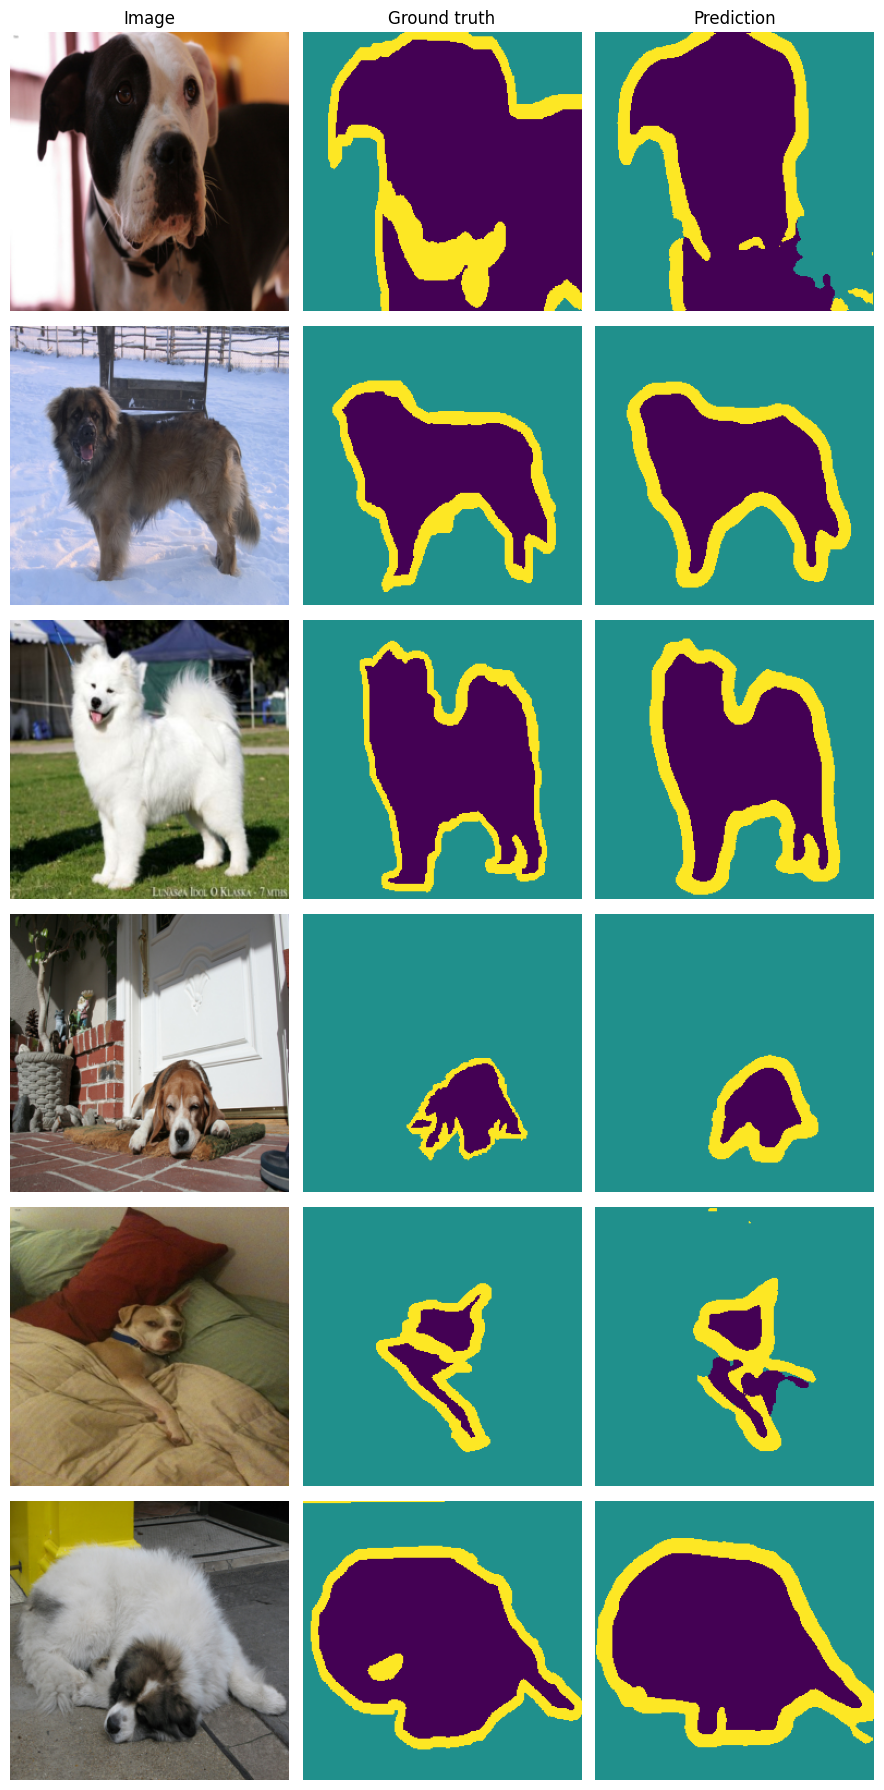

In [23]:
torch.manual_seed(1)
idxs = torch.randperm(len(test_set))[:6].tolist()       # six random test images
xb = torch.stack([test_set[i][0] for i in idxs])
yb = torch.stack([test_set[i][1] for i in idxs])

model.eval()
with torch.no_grad(), torch.autocast('cuda', dtype=torch.float16):
    pred = model(xb.to(device)).argmax(dim=1).cpu()

fig, ax = plt.subplots(6, 3, figsize=(9, 18))
for r in range(6):
    im = (xb[r] * std + mean).clamp(0, 1).permute(1, 2, 0)
    ax[r, 0].imshow(im)
    ax[r, 1].imshow(yb[r],   vmin=0, vmax=2)
    ax[r, 2].imshow(pred[r], vmin=0, vmax=2)
    for c in range(3):
        ax[r, c].axis('off')
ax[0, 0].set_title('Image'); ax[0, 1].set_title('Ground truth'); ax[0, 2].set_title('Prediction')

plt.tight_layout()
plt.savefig(CKPT_DIR / 'predictions.png', dpi=150, bbox_inches='tight')
plt.show()

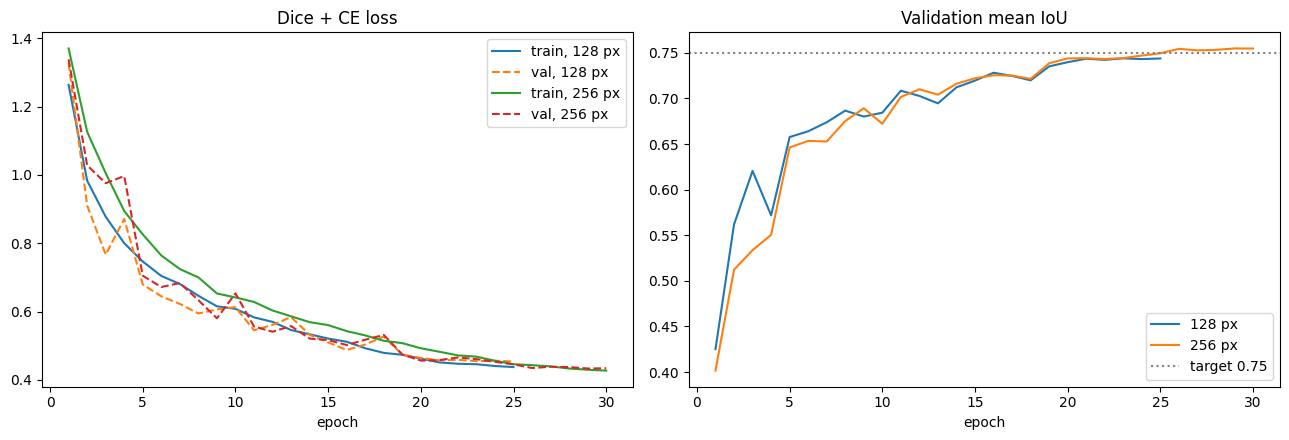

In [24]:
h1 = torch.load(CKPT_DIR / 'run1_128px_history.pt')
h2 = torch.load(CKPT_DIR / 'run2_256px_history.pt')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for h, name in [(h1, '128 px'), (h2, '256 px')]:
    ep = range(1, len(h['train_loss']) + 1)
    ax[0].plot(ep, h['train_loss'], label=f'train, {name}')
    ax[0].plot(ep, h['val_loss'], linestyle='--', label=f'val, {name}')
    ax[1].plot(ep, h['val_miou'], label=name)

ax[0].set_title('Dice + CE loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].axhline(0.75, color='gray', linestyle=':', label='target 0.75')
ax[1].set_title('Validation mean IoU'); ax[1].set_xlabel('epoch'); ax[1].legend()

plt.tight_layout()
plt.savefig(CKPT_DIR / 'curves.png', dpi=150, bbox_inches='tight')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


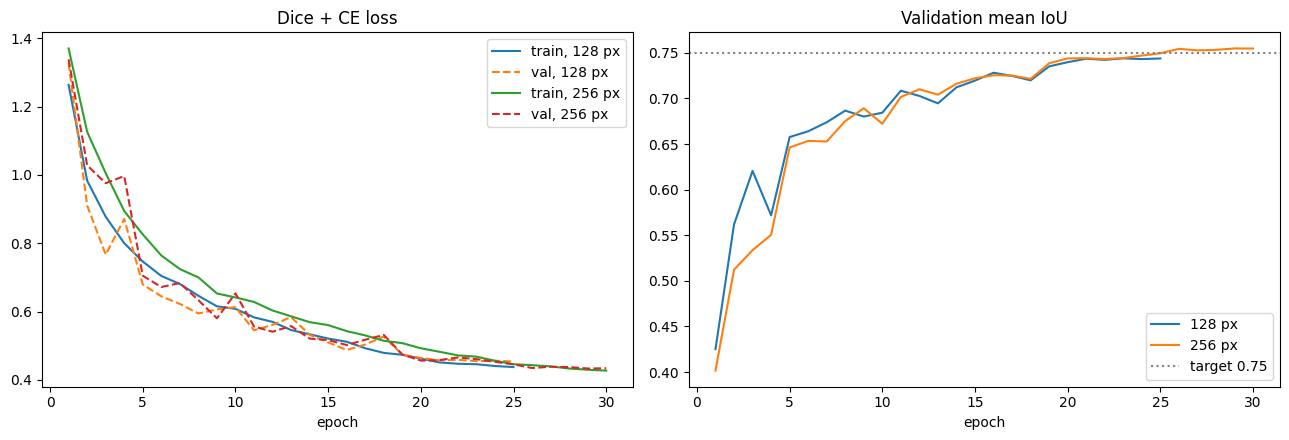

In [2]:

from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')
CKPT_DIR = Path('/content/drive/MyDrive/unet-pet')

h1 = torch.load(CKPT_DIR / 'run1_128px_history.pt')
h2 = torch.load(CKPT_DIR / 'run2_256px_history.pt')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for h, name in [(h1, '128 px'), (h2, '256 px')]:
    ep = range(1, len(h['train_loss']) + 1)
    ax[0].plot(ep, h['train_loss'], label=f'train, {name}')
    ax[0].plot(ep, h['val_loss'], linestyle='--', label=f'val, {name}')
    ax[1].plot(ep, h['val_miou'], label=name)

ax[0].set_title('Dice + CE loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].axhline(0.75, color='gray', linestyle=':', label='target 0.75')
ax[1].set_title('Validation mean IoU'); ax[1].set_xlabel('epoch'); ax[1].legend()

plt.tight_layout()
plt.savefig(CKPT_DIR / 'curves.png', dpi=150, bbox_inches='tight')
plt.show()